# Integrated EDA

In [ ]:
from dotenv import load_dotenv
load_dotenv()


In [4]:
import io
import itertools
import os
import tempfile
from pathlib import Path
from typing import Optional

import boto3

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


In [5]:
BUCKET_NAME = os.environ["BUCKET_NAME"]
OUTPUT_PREFIX = os.environ.get("INTEGRATED_OUTPUT_PREFIX", "integrated/monthly_base")
INTEGRATED_FILENAME = "integrated_monthly_base.parquet"

s3 = boto3.client("s3")


def find_latest_integrated_key(bucket: str, prefix: str) -> str:
    normalized_prefix = prefix.strip("/")
    paginator = s3.get_paginator("list_objects_v2")
    candidates = []

    for page in paginator.paginate(Bucket=bucket, Prefix=f"{normalized_prefix}/run_date="):
        for obj in page.get("Contents", []):
            key = obj["Key"]
            if key.endswith(f"/{INTEGRATED_FILENAME}"):
                candidates.append(key)

    if not candidates:
        raise FileNotFoundError(
            f"No {INTEGRATED_FILENAME} objects found under "
            f"s3://{bucket}/{normalized_prefix}/run_date=*/"
        )

    return max(candidates)


integrated_key = os.environ.get("INTEGRATED_KEY") or find_latest_integrated_key(
    BUCKET_NAME,
    OUTPUT_PREFIX,
)

print(f"Reading integrated data from s3://{BUCKET_NAME}/{integrated_key}")
obj = s3.get_object(Bucket=BUCKET_NAME, Key=integrated_key)
df_integrated = pd.read_parquet(io.BytesIO(obj["Body"].read()))

df_integrated["date"] = pd.to_datetime(df_integrated["date"], errors="coerce")
df_integrated = df_integrated.sort_values("date").reset_index(drop=True)


Reading integrated data from s3://jolese-transit-ml-portfolio-367995857052-us-east-1-an/integrated/monthly_base/run_date=2026-05-15/integrated_monthly_base.parquet


In [6]:
df_integrated.tail(5)

,date,period_end,transit_available_at,transit_series_id,transit_source_name,upt,vrm,vrh,voms,gas_available_at,...,gas_source_name,seattle_gas_price_avg,seattle_gas_price_std,weekly_obs_count,inflation_available_at,inflation_series_id,inflation_source_name,cpi_all_items_sa,cpi_core_sa,data_available_at
286,2025-11-01,2025-11-30,2025-12-07,king_county_mb_do_bus,ntd_complete_monthly_ridership_workbook,6034095.0,2569323.0,244071.0,741.0,2025-12-07,...,eia_seattle_gas_prices,4.4425,0.040862,4.0,2025-12-07,fred_monthly_inflation,fred_inflation,325.063,331.043,2025-12-07
287,2025-12-01,2025-12-31,2026-01-07,king_county_mb_do_bus,ntd_complete_monthly_ridership_workbook,5848180.0,2727319.0,259345.0,745.0,2026-01-07,...,eia_seattle_gas_prices,4.3004,0.092110,5.0,2026-01-07,fred_monthly_inflation,fred_inflation,326.031,331.814,2026-01-07
288,2026-01-01,2026-01-31,2026-02-07,king_county_mb_do_bus,ntd_complete_monthly_ridership_workbook,6315539.0,2521456.0,245293.0,752.0,2026-02-07,...,eia_seattle_gas_prices,4.0705,0.050395,4.0,2026-02-07,fred_monthly_inflation,fred_inflation,326.588,332.793,2026-02-07
289,2026-02-01,2026-02-28,2026-03-07,king_county_mb_do_bus,ntd_complete_monthly_ridership_workbook,5912095.0,2318820.0,226557.0,770.0,2026-03-07,...,eia_seattle_gas_prices,4.3010,0.180877,4.0,2026-03-07,fred_monthly_inflation,fred_inflation,327.460,333.512,2026-03-07
290,2026-03-01,2026-03-31,2026-04-07,king_county_mb_do_bus,ntd_complete_monthly_ridership_workbook,6646228.0,2581034.0,251947.0,776.0,2026-04-07,...,eia_seattle_gas_prices,5.0632,0.410611,5.0,2026-04-07,fred_monthly_inflation,fred_inflation,330.293,334.165,2026-04-07


In [7]:
df_numeric_features_only = df_integrated[["date","upt","vrm","vrh","voms","seattle_gas_price_avg","seattle_gas_price_std","cpi_all_items_sa","cpi_core_sa"]]

df_numeric_features_only.head()

,date,upt,vrm,vrh,voms,seattle_gas_price_avg,seattle_gas_price_std,cpi_all_items_sa,cpi_core_sa
0,2002-01-01,6045861.0,2878549.0,216788.0,931.0,NaN,NaN,177.7,188.7
1,2002-02-01,5406135.0,2558164.0,192360.0,931.0,NaN,NaN,178.0,189.1
2,2002-03-01,5999230.0,2840121.0,213519.0,931.0,NaN,NaN,178.5,189.2
3,2002-04-01,6058398.0,2855047.0,213860.0,931.0,NaN,NaN,179.3,189.7
4,2002-05-01,6134503.0,2899399.0,217418.0,931.0,NaN,NaN,179.5,190.0


In [8]:
df_numeric_features_only.tail(10)

,date,upt,vrm,vrh,voms,seattle_gas_price_avg,seattle_gas_price_std,cpi_all_items_sa,cpi_core_sa
281,2025-06-01,6688867.0,2630448.0,250100.0,739.0,4.56860,0.037534,321.435,327.658
282,2025-07-01,6716230.0,2727319.0,259345.0,748.0,4.55450,0.023812,322.169,328.682
283,2025-08-01,6629625.0,2697388.0,256443.0,740.0,4.54525,0.017347,323.291,329.700
284,2025-09-01,6597525.0,2630448.0,250100.0,745.0,4.67860,0.104777,324.245,330.418
285,2025-10-01,7027582.0,2758513.0,262473.0,742.0,4.63075,0.054537,NaN,NaN
286,2025-11-01,6034095.0,2569323.0,244071.0,741.0,4.44250,0.040862,325.063,331.043
287,2025-12-01,5848180.0,2727319.0,259345.0,745.0,4.30040,0.092110,326.031,331.814
288,2026-01-01,6315539.0,2521456.0,245293.0,752.0,4.07050,0.050395,326.588,332.793
289,2026-02-01,5912095.0,2318820.0,226557.0,770.0,4.30100,0.180877,327.460,333.512
290,2026-03-01,6646228.0,2581034.0,251947.0,776.0,5.06320,0.410611,330.293,334.165


In [9]:
nan_count = df_numeric_features_only['seattle_gas_price_avg'].isna().sum()
print(f"Number of rows with NaN in 'seattle_gas_price_avg': {nan_count}")

Number of rows with NaN in 'seattle_gas_price_avg': 16


In [10]:
# Keep the monthly calendar intact. Missing exogenous values get imputed and flagged;
# rows are dropped only if core observed transit inputs are missing.
def fill_trailing_with_recent_trend(series: pd.Series, window: int = 5) -> pd.Series:
    filled = series.copy()

    while filled.isna().any():
        missing_positions = np.flatnonzero(filled.isna().to_numpy())
        pos = missing_positions[0]

        # Only use this for new trailing gaps. Interior gaps are handled by interpolation.
        if pos < len(filled) - 1 and filled.iloc[pos + 1:].notna().any():
            break

        history = filled.iloc[:pos].dropna().tail(window)
        if len(history) >= 2:
            x = np.arange(len(history), dtype=float)
            slope, intercept = np.polyfit(x, history.to_numpy(dtype=float), 1)
            filled.iloc[pos] = intercept + slope * len(history)
        elif len(history) == 1:
            filled.iloc[pos] = history.iloc[-1]
        else:
            break

    return filled


def impute_exogenous_monthly_values(df: pd.DataFrame, cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    working = df.copy()
    imputation_records = []

    for col in cols:
        if col not in working.columns:
            continue

        original = working[col].copy()
        original_missing = original.isna()

        working[f"{col}_was_imputed"] = 0
        working[f"{col}_imputed_interpolated"] = 0
        working[f"{col}_imputed_trailing_trend"] = 0

        interpolated = original.interpolate(method="linear", limit_area="inside")
        interpolated_positions = original_missing & interpolated.notna()

        trended = fill_trailing_with_recent_trend(interpolated, window=5)
        trended_positions = original_missing & interpolated.isna() & trended.notna()

        working[col] = trended
        working.loc[original_missing & working[col].notna(), f"{col}_was_imputed"] = 1
        working.loc[interpolated_positions, f"{col}_imputed_interpolated"] = 1
        working.loc[trended_positions, f"{col}_imputed_trailing_trend"] = 1

        for idx in working.index[original_missing & working[col].notna()]:
            if interpolated_positions.loc[idx]:
                method = "linear_interpolation_between_observed_months"
            elif trended_positions.loc[idx]:
                method = "five_month_recent_trend_projection"
            else:
                method = "unknown"

            imputation_records.append({
                "date": working.loc[idx, "date"],
                "column": col,
                "method": method,
                "imputed_value": working.loc[idx, col],
            })

    imputation_log = pd.DataFrame(imputation_records)
    return working, imputation_log


core_observed_cols = ["date", "upt", "vrm", "vrh", "voms"]
exogenous_cols_to_impute = [
    "seattle_gas_price_avg",
    "seattle_gas_price_std",
    "cpi_all_items_sa",
    "cpi_core_sa",
]

df_numeric_features_only = df_numeric_features_only.sort_values("date").reset_index(drop=True)
df_numeric_features_only, exogenous_imputation_log = impute_exogenous_monthly_values(
    df_numeric_features_only,
    exogenous_cols_to_impute,
)

df_numeric_features_only = (
    df_numeric_features_only
    .dropna(subset=core_observed_cols)
    .sort_values("date")
    .reset_index(drop=True)
)

print("Exogenous imputations:", len(exogenous_imputation_log))
display(exogenous_imputation_log)


In [11]:
df_numeric_features_only_trimmed = df_numeric_features_only.copy()

In [12]:
df_numeric_features_only_trimmed.head()

,date,upt,vrm,vrh,voms,seattle_gas_price_avg,seattle_gas_price_std,cpi_all_items_sa,cpi_core_sa
0,2003-05-01,6018871.0,2893190.0,217503.0,931.0,1.57400,0.000000,182.9,192.9
1,2003-06-01,5766180.0,2829145.0,212087.0,931.0,1.59080,0.026985,183.1,193.0
2,2003-07-01,5946970.0,2938717.0,220105.0,931.0,1.62175,0.016174,183.7,193.4
3,2003-08-01,5828996.0,2882080.0,216402.0,931.0,1.77975,0.158401,184.5,193.6
4,2003-09-01,5715720.0,2847550.0,213518.0,931.0,1.88740,0.079226,185.1,193.7


In [ ]:
def add_time_and_regime_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
    df = df.sort_values("date").reset_index(drop=True)

    df["time_index_months"] = np.arange(len(df))
    df["month_num"] = df["date"].dt.month

    df["month_sin"] = np.sin(2 * np.pi * df["month_num"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month_num"] / 12)

    covid_start = pd.Timestamp("2020-03-01")
    post_covid_start = pd.Timestamp("2021-03-01")

    df["is_covid_disruption"] = (
        (df["date"] >= covid_start) & (df["date"] < post_covid_start)
    ).astype(int)

    df["is_post_covid"] = (df["date"] >= post_covid_start).astype(int)

    df["months_since_covid_impact"] = np.where(
        df["date"] >= covid_start,
        (
            (df["date"].dt.year - covid_start.year) * 12
            + (df["date"].dt.month - covid_start.month)
        ),
        0
    )

    return df


def add_lagged_features_for_group(
    df: pd.DataFrame,
    cols: list[str],
    lags: list[int],
    rolling_windows: list[int],
    diff_lags: list[int],
    add_yoy_diff: bool = True,
    add_yoy_pct: bool = False,
    add_rollstd: bool = True,
) -> pd.DataFrame:
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
    df = df.sort_values("date").reset_index(drop=True)

    for col in cols:
        if col not in df.columns:
            raise ValueError(f"Column not found in dataframe: {col}")

        # raw lag values
        for lag in lags:
            df[f"{col}_lag{lag}"] = df[col].shift(lag)

        # lagged differences
        for lag in diff_lags:
            df[f"{col}_diff_lag{lag}"] = df[col].shift(lag) - df[col].shift(lag + 1)

        # rolling summaries from past data only
        lagged = df[col].shift(1)

        for window in rolling_windows:
            df[f"{col}_rollmean_{window}"] = lagged.rolling(window).mean()
            if add_rollstd:
                df[f"{col}_rollstd_{window}"] = lagged.rolling(window).std()

        # YoY features
        if add_yoy_diff:
            df[f"{col}_yoy_diff"] = df[col].shift(1) - df[col].shift(13)

        if add_yoy_pct:
            prev_year = df[col].shift(13)
            df[f"{col}_yoy_pct"] = np.where(
                prev_year != 0,
                (df[col].shift(1) - prev_year) / prev_year,
                np.nan
            )

    return df


def add_target_horizon(
    df: pd.DataFrame,
    target_col: str,
    horizon: int,
    date_col: str = "date",
) -> pd.DataFrame:
    df = df.copy()
    df[date_col] = pd.to_datetime(
        df[date_col],
        errors="coerce"
    ).dt.to_period("M").dt.to_timestamp()

    df = df.sort_values(date_col).reset_index(drop=True)
    target_date_col = f"target_date_h{horizon}"
    target_value_col = f"{target_col}_target_h{horizon}"

    df[target_date_col] = df[date_col] + pd.DateOffset(months=horizon)

    target_lookup = df[[date_col, target_col]].rename(
        columns={date_col: target_date_col, target_col: target_value_col}
    )
    df = df.merge(target_lookup, on=target_date_col, how="left")

    df[f"target_month_num_h{horizon}"] = df[target_date_col].dt.month

    df[f"target_month_sin_h{horizon}"] = np.sin(
        2 * np.pi * df[f"target_month_num_h{horizon}"] / 12
    )
    df[f"target_month_cos_h{horizon}"] = np.cos(
        2 * np.pi * df[f"target_month_num_h{horizon}"] / 12
    )

    return df


def build_feature_table(
    df: pd.DataFrame,
    target_col: str = "upt",
    horizon: int = 3,
) -> pd.DataFrame:
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
    df = df.sort_values("date").reset_index(drop=True)

    df = add_time_and_regime_features(df)

    upt_cols = ["upt"]

    service_cols = [
        "vrm",
        "vrh",
        "voms",
    ]

    exogenous_cols = [
        "seattle_gas_price_avg",
        "seattle_gas_price_std",
        "cpi_all_items_sa",
        "cpi_core_sa",
    ]

    service_cols = [col for col in service_cols if col in df.columns]
    exogenous_cols = [col for col in exogenous_cols if col in df.columns]

    # Dense memory for UPT
    df = add_lagged_features_for_group(
        df,
        cols=upt_cols,
        lags=list(range(1, 13)) + [18, 24],
        rolling_windows=[3, 6],
        diff_lags=[1, 2, 3],
        add_yoy_diff=True,
        add_yoy_pct=False,
        add_rollstd=True,
    )

    # Lighter lag set for service variables
    df = add_lagged_features_for_group(
        df,
        cols=service_cols,
        lags=[1, 3, 6, 12],
        rolling_windows=[3, 6],
        diff_lags=[1, 3],
        add_yoy_diff=True,
        add_yoy_pct=False,
        add_rollstd=False,
    )

    # Recent-focused lag set for exogenous variables
    df = add_lagged_features_for_group(
        df,
        cols=exogenous_cols,
        lags=[1, 2, 3, 6, 12],
        rolling_windows=[3],
        diff_lags=[1, 3],
        add_yoy_diff=True,
        add_yoy_pct=False,
        add_rollstd=False,
    )

    df = add_target_horizon(
        df,
        target_col=target_col,
        horizon=horizon,
        date_col="date",
    )

    return df


df_feature_base = df_numeric_features_only_trimmed.copy()

df_feature_base["date"] = pd.to_datetime(
    df_feature_base["date"],
    errors="coerce"
).dt.to_period("M").dt.to_timestamp()

feature_table_h3 = build_feature_table(
    df=df_feature_base,
    target_col="upt",
    horizon=3,
)



def make_feature_set_library(feature_table: pd.DataFrame) -> dict[str, list[str]]:
    target_cols = {"upt_target_h3", "target_date_h3"}
    metadata_cols = {"date"}

    passthrough_cols = [
        "month_num",
        "month_sin",
        "month_cos",
        "target_month_num_h3",
        "target_month_sin_h3",
        "target_month_cos_h3",
        "is_covid_disruption",
        "is_post_covid",
        "months_since_covid_impact",
    ]
    history_cols = [c for c in feature_table.columns if c.startswith("upt_") and c not in target_cols]
    service_cols = [c for c in feature_table.columns if c.startswith(("vrm_", "vrh_", "voms_"))]
    gas_cols = [c for c in feature_table.columns if c.startswith("seattle_gas_price_")]
    inflation_cols = [c for c in feature_table.columns if c.startswith(("cpi_all_items_sa_", "cpi_core_sa_"))]
    regime_cols = [c for c in passthrough_cols if c in feature_table.columns]

    library = {
        "history_only": history_cols,
        "history_regime": history_cols + regime_cols,
        "history_regime_service": history_cols + regime_cols + service_cols,
        "history_regime_gas_cpi": history_cols + regime_cols + gas_cols + inflation_cols,
        "history_regime_all_exog": history_cols + regime_cols + service_cols + gas_cols + inflation_cols,
    }

    return {
        name: [c for c in dict.fromkeys(cols) if c in feature_table.columns and c not in metadata_cols]
        for name, cols in library.items()
    }


feature_set_library = make_feature_set_library(feature_table_h3)
{key: len(value) for key, value in feature_set_library.items()}

feature_table_h3.head(20)

,date,upt,vrm,vrh,voms,seattle_gas_price_avg,seattle_gas_price_std,cpi_all_items_sa,cpi_core_sa,time_index_months,...,cpi_core_sa_lag12,cpi_core_sa_diff_lag1,cpi_core_sa_diff_lag3,cpi_core_sa_rollmean_3,cpi_core_sa_yoy_diff,upt_target_h3,target_date_h3,target_month_num_h3,target_month_sin_h3,target_month_cos_h3
0,2003-05-01,6018871.0,2893190.0,217503.0,931.0,1.57400,0.000000,182.9,192.9,0,...,NaN,NaN,NaN,NaN,NaN,5828996.0,2003-08-01,8,-8.660254e-01,-5.000000e-01
1,2003-06-01,5766180.0,2829145.0,212087.0,931.0,1.59080,0.026985,183.1,193.0,1,...,NaN,NaN,NaN,NaN,NaN,5715720.0,2003-09-01,9,-1.000000e+00,-1.836970e-16
2,2003-07-01,5946970.0,2938717.0,220105.0,931.0,1.62175,0.016174,183.7,193.4,2,...,NaN,0.1,NaN,NaN,NaN,6088824.0,2003-10-01,10,-8.660254e-01,5.000000e-01
3,2003-08-01,5828996.0,2882080.0,216402.0,931.0,1.77975,0.158401,184.5,193.6,3,...,NaN,0.4,NaN,193.100000,NaN,5400923.0,2003-11-01,11,-5.000000e-01,8.660254e-01
4,2003-09-01,5715720.0,2847550.0,213518.0,931.0,1.88740,0.079226,185.1,193.7,4,...,NaN,0.2,0.1,193.333333,NaN,5926597.0,2003-12-01,12,-2.449294e-16,1.000000e+00
5,2003-10-01,6088824.0,3105232.0,232869.0,931.0,1.65725,0.056275,184.9,194.0,5,...,NaN,0.1,0.4,193.566667,NaN,6093909.0,2004-01-01,1,5.000000e-01,8.660254e-01
6,2003-11-01,5400923.0,2792736.0,211580.0,931.0,1.58950,0.010536,185.0,194.0,6,...,NaN,0.3,0.2,193.766667,NaN,5751219.0,2004-02-01,2,8.660254e-01,5.000000e-01
7,2003-12-01,5926597.0,3031519.0,228023.0,931.0,1.53680,0.031428,185.5,194.2,7,...,NaN,0.0,0.1,193.900000,NaN,6567769.0,2004-03-01,3,1.000000e+00,6.123234e-17
8,2004-01-01,6093909.0,3002856.0,225614.0,1183.0,1.63700,0.066883,186.3,194.6,8,...,NaN,0.2,0.3,194.066667,NaN,6319709.0,2004-04-01,4,8.660254e-01,-5.000000e-01
9,2004-02-01,5751219.0,2751058.0,206981.0,1183.0,1.72750,0.031554,186.7,194.9,9,...,NaN,0.4,0.0,194.266667,NaN,6127029.0,2004-05-01,5,5.000000e-01,-8.660254e-01


In [14]:
feature_table_h3["upt_lag36"]


0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
         ...    
269    5267823.0
270    4698068.0
271    4172608.0
272    4903992.0
273    4624888.0
Name: upt_lag36, Length: 274, dtype: float64

In [15]:
#printing names of columns in feature_table_h3 that contain the "upt"
for col in feature_table_h3.columns:
    if "upt" in col:
        print(col)

upt
is_covid_disruption
upt_lag1
upt_lag2
upt_lag3
upt_lag4
upt_lag5
upt_lag6
upt_lag7
upt_lag8
upt_lag9
upt_lag10
upt_lag11
upt_lag12
upt_lag18
upt_lag24
upt_lag30
upt_lag36
upt_diff_lag1
upt_diff_lag2
upt_diff_lag3
upt_rollmean_3
upt_rollstd_3
upt_rollmean_6
upt_rollstd_6
upt_yoy_diff
upt_target_h3


In [16]:
def add_seasonal_naive_proxy(
    df: pd.DataFrame,
    target_col: str,
    seasonal_periods: int = 12,
) -> pd.DataFrame:
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
    df = df.sort_values("date").reset_index(drop=True)

    df["seasonal_naive_proxy"] = df[target_col].shift(seasonal_periods)
    return df

In [17]:
def directional_accuracy(actual, pred):
    actual_diff = np.sign(np.diff(actual))
    pred_diff = np.sign(np.diff(pred))
    return (actual_diff == pred_diff).mean() if len(actual_diff) > 0 else np.nan


def run_xgb_experiment(
    df: pd.DataFrame,
    feature_cols: list[str],
    params: dict,
    target_col: str = "upt_target_h3",
    split_date: str = "2025-01-01",
    valid_start_date: Optional[str] = None,
    mode: str = "raw",   # "raw" or "residual"
):
    work = df.copy()
    work["date"] = pd.to_datetime(work["date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
    work = work.sort_values("date").reset_index(drop=True)

    missing_features = [c for c in feature_cols if c not in work.columns]
    if missing_features:
        raise ValueError(f"Missing feature columns: {missing_features[:10]}")

    needed_cols = ["date", target_col] + feature_cols
    work = work[needed_cols].copy()

    # Correctly aligned seasonal naive baseline for the target itself
    work = add_seasonal_naive_proxy(work, target_col=target_col, seasonal_periods=12)

    # Drop rows only after seasonal proxy exists. The proxy is needed for benchmark metrics in both modes.
    if mode == "raw":
        work = work.dropna(subset=feature_cols + [target_col, "seasonal_naive_proxy"]).copy()
    elif mode == "residual":
        work = work.dropna(subset=feature_cols + [target_col, "seasonal_naive_proxy"]).copy()
    else:
        raise ValueError("mode must be 'raw' or 'residual'")

    split_date = pd.Timestamp(split_date)

    train_df = work[work["date"] < split_date].copy()
    valid_df = work[work["date"] >= split_date].copy()

    # Optional inner validation start if you want a 2024-only validation like old notebook
    if valid_start_date is not None:
        valid_start_date = pd.Timestamp(valid_start_date)
        train_full = train_df.copy()
        valid_df = train_full[train_full["date"] >= valid_start_date].copy()
        train_df = train_full[train_full["date"] < valid_start_date].copy()

    if train_df.empty or valid_df.empty:
        raise ValueError(
            f"Empty train/validation split: n_train={len(train_df)}, n_valid={len(valid_df)}. "
            "Check split_date, valid_start_date, and feature availability."
        )

    X_train = train_df[feature_cols]
    X_valid = valid_df[feature_cols]

    if mode == "raw":
        y_train = train_df[target_col]
        y_valid = valid_df[target_col]
    else:
        y_train = train_df[target_col] - train_df["seasonal_naive_proxy"]
        y_valid = valid_df[target_col] - valid_df["seasonal_naive_proxy"]

    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        **params,
    )
    model.fit(X_train, y_train)

    pred_valid = model.predict(X_valid)

    if mode == "residual":
        pred_valid = valid_df["seasonal_naive_proxy"].values + pred_valid

    actual_valid = valid_df[target_col].values
    naive_valid = valid_df["seasonal_naive_proxy"].values

    return {
        "feature_cols": feature_cols,
        "n_features": len(feature_cols),
        "mode": mode,
        "n_train": len(train_df),
        "n_valid": len(valid_df),
        "mae_valid": mean_absolute_error(actual_valid, pred_valid),
        "rmse_valid": mean_squared_error(actual_valid, pred_valid) ** 0.5,
        "r2_valid": r2_score(actual_valid, pred_valid),
        "diracc_valid": directional_accuracy(actual_valid, pred_valid),
        "mae_naive_valid": mean_absolute_error(actual_valid, naive_valid),
        "rmse_naive_valid": mean_squared_error(actual_valid, naive_valid) ** 0.5,
        "pred_valid": pred_valid,
        "actual_valid": actual_valid,
        "naive_valid": naive_valid,
        "valid_dates": valid_df["date"].values,
        "model": model,
    }

In [18]:
target_col = "upt_target_h3"

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [3, 4],
    "learning_rate": [0.05, 0.10],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9],
    "min_child_weight": [1, 3],
}

grid_keys = list(param_grid.keys())
grid_values = list(param_grid.values())
param_combos = [dict(zip(grid_keys, vals)) for vals in itertools.product(*grid_values)]

results = []

for feature_family_name, feature_cols_raw in feature_set_library.items():
    feature_cols = [c for c in feature_cols_raw if c in feature_table_h3.columns]

    for mode in ["raw", "residual"]:
        for params in param_combos:
            out = run_xgb_experiment(
                df=feature_table_h3,
                feature_cols=feature_cols,
                params=params,
                target_col=target_col,
                split_date="2025-01-01",
                mode=mode,
            )

            results.append({
                "feature_family_name": feature_family_name,
                "mode": mode,
                "n_features": out["n_features"],
                "n_train": out["n_train"],
                "n_valid": out["n_valid"],
                **params,
                "mae_valid": out["mae_valid"],
                "rmse_valid": out["rmse_valid"],
                "r2_valid": out["r2_valid"],
                "diracc_valid": out["diracc_valid"],
                "mae_naive_valid": out["mae_naive_valid"],
                "rmse_naive_valid": out["rmse_naive_valid"],
                "mae_improvement_vs_naive": out["mae_naive_valid"] - out["mae_valid"],
                "rmse_improvement_vs_naive": out["rmse_naive_valid"] - out["rmse_valid"],
            })

results_df = pd.DataFrame(results).sort_values("rmse_valid").reset_index(drop=True)
results_df.head(20)

,feature_family_name,mode,n_features,n_train,n_valid,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,mae_valid,rmse_valid,r2_valid,diracc_valid,mae_naive_valid,rmse_naive_valid,mae_improvement_vs_naive,rmse_improvement_vs_naive
0,history_regime_gas_cpi,raw,71,224,11,500,4,0.10,0.9,0.9,3,320028.727273,337484.192123,0.156138,0.4,584735.454545,624481.775011,264706.727273,286997.582888
1,history_regime_gas_cpi,raw,71,224,11,200,4,0.10,0.9,0.9,3,320356.045455,337648.788130,0.155315,0.4,584735.454545,624481.775011,264379.409091,286832.986881
2,history_regime_gas_cpi,raw,71,224,11,200,3,0.10,0.9,0.9,3,351164.636364,365521.632527,0.010102,0.3,584735.454545,624481.775011,233570.818182,258960.142484
3,history_regime_gas_cpi,raw,71,224,11,500,3,0.10,0.9,0.9,3,353014.727273,367487.536072,-0.000575,0.3,584735.454545,624481.775011,231720.727273,256994.238939
4,history_regime_gas_cpi,raw,71,224,11,500,3,0.05,0.9,0.9,3,358636.545455,370668.761147,-0.017973,0.5,584735.454545,624481.775011,226098.909091,253813.013865
5,history_regime_gas_cpi,raw,71,224,11,200,3,0.05,0.9,0.9,3,368543.272727,379774.072973,-0.068600,0.4,584735.454545,624481.775011,216192.181818,244707.702038
6,history_regime_gas_cpi,raw,71,224,11,500,3,0.05,0.9,0.8,3,372724.272727,385069.163302,-0.098606,0.3,584735.454545,624481.775011,212011.181818,239412.611709
7,history_regime_gas_cpi,raw,71,224,11,500,4,0.05,0.9,0.9,3,353897.636364,389071.670915,-0.121563,0.4,584735.454545,624481.775011,230837.818182,235410.104096
8,history_regime_gas_cpi,raw,71,224,11,200,4,0.05,0.9,0.9,3,356503.500000,392277.992306,-0.140125,0.4,584735.454545,624481.775011,228231.954545,232203.782706
9,history_regime_gas_cpi,raw,71,224,11,200,3,0.10,0.8,0.8,3,368143.772727,393209.622097,-0.145547,0.3,584735.454545,624481.775011,216591.681818,231272.152914


In [19]:
summary_by_family_mode = (
    results_df.groupby(["feature_family_name", "mode"])
    .agg(
        best_rmse=("rmse_valid", "min"),
        best_mae=("mae_valid", "min"),
        best_r2=("r2_valid", "max"),
        best_diracc=("diracc_valid", "max"),
        best_rmse_improvement_vs_naive=("rmse_improvement_vs_naive", "max"),
        best_mae_improvement_vs_naive=("mae_improvement_vs_naive", "max"),
        avg_rmse=("rmse_valid", "mean"),
        avg_mae=("mae_valid", "mean"),
    )
    .sort_values("best_rmse")
    .reset_index()
)

summary_by_family_mode

,feature_family_name,mode,best_rmse,best_mae,best_r2,best_diracc,best_rmse_improvement_vs_naive,best_mae_improvement_vs_naive,avg_rmse,avg_mae
0,history_regime_gas_cpi,raw,337484.192123,320028.727273,0.156138,0.5,286997.582888,264706.727273,439682.753525,405402.843750
1,history_regime,raw,405239.405363,370148.909091,-0.216712,0.4,219242.369648,214586.545455,502550.030255,447790.785511
2,history_regime_all_exog,raw,463732.793770,427898.318182,-0.593309,0.6,160748.981242,156837.136364,552949.193613,487968.176136
3,history_regime_service,raw,508650.773271,474658.000000,-0.916920,0.3,115831.001740,110077.454545,639509.937963,553751.115057
4,history_regime_gas_cpi,residual,541922.045924,338015.440341,-1.175896,0.5,82559.729087,246720.014205,581100.222974,359658.634144
5,history_only,residual,551527.239492,345578.136364,-1.253712,0.5,72954.535519,239157.318182,573883.752137,374237.151767
6,history_regime,residual,551829.686227,374680.139205,-1.256184,0.5,72652.088784,210055.315341,590726.368429,395413.219534
7,history_only,raw,624665.414858,534864.954545,-1.891075,0.4,-183.639847,49870.500000,706821.973598,629203.460227
8,history_regime_all_exog,residual,651271.539298,423146.903409,-2.142597,0.5,-26789.764286,161588.551136,798605.275408,490810.600186
9,history_regime_service,residual,736911.758124,464511.625000,-3.023421,0.6,-112429.983113,120223.829545,849201.953338,513087.734020


      feature_family_name mode     rmse_valid      mae_valid  r2_valid  \
0  history_regime_gas_cpi  raw  337484.192123  320028.727273  0.156138   
1  history_regime_gas_cpi  raw  337648.788130  320356.045455  0.155315   
2  history_regime_gas_cpi  raw  365521.632527  351164.636364  0.010102   

   diracc_valid  n_estimators  max_depth  learning_rate  subsample  \
0           0.4           500          4            0.1        0.9   
1           0.4           200          4            0.1        0.9   
2           0.3           200          3            0.1        0.9   

   colsample_bytree  min_child_weight  
0               0.9                 3  
1               0.9                 3  
2               0.9                 3  
         date     actual  seasonal_naive_pred  pred_top1  pred_top2  pred_top3
0  2025-01-01  6841791.0            6108964.0  6579018.0  6579839.0  6444359.0
1  2025-02-01  6973406.0            6401486.0  6471627.0  6472969.5  6348677.5
2  2025-03-01  6688867.0 

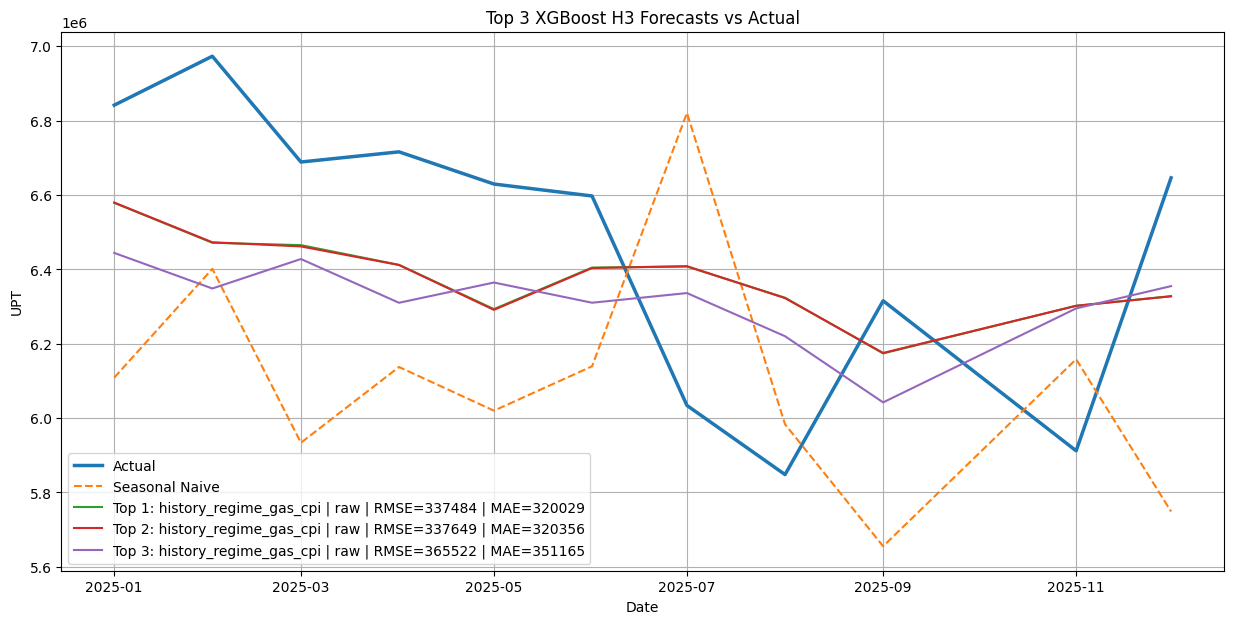

In [20]:
# ---------------------------------------------------
# choose the top 3 model configurations from results_df
# ---------------------------------------------------
top3_runs = results_df.nsmallest(min(3, len(results_df)), "rmse_valid").copy().reset_index(drop=True)
print(top3_runs[[
    "feature_family_name", "mode", "rmse_valid", "mae_valid", "r2_valid", "diracc_valid",
    "n_estimators", "max_depth", "learning_rate", "subsample", "colsample_bytree", "min_child_weight"
]])

# ---------------------------------------------------
# rerun those exact 3 experiments to recover forecasts
# ---------------------------------------------------
top3_outputs = []

for i, row in top3_runs.iterrows():
    family_name = row["feature_family_name"]
    mode = row["mode"]

    feature_cols = [c for c in feature_set_library[family_name] if c in feature_table_h3.columns]

    params = {
        "n_estimators": int(row["n_estimators"]),
        "max_depth": int(row["max_depth"]),
        "learning_rate": float(row["learning_rate"]),
        "subsample": float(row["subsample"]),
        "colsample_bytree": float(row["colsample_bytree"]),
        "min_child_weight": float(row["min_child_weight"]),
    }

    out = run_xgb_experiment(
        df=feature_table_h3,
        feature_cols=feature_cols,
        params=params,
        target_col="upt_target_h3",
        split_date="2025-01-01",
        mode=mode,
    )

    pred_col = f"pred_top{i+1}"
    label = (
        f"Top {i+1}: {family_name} | {mode} | "
        f"RMSE={row['rmse_valid']:.0f} | MAE={row['mae_valid']:.0f}"
    )

    forecast_df = pd.DataFrame({
        "date": pd.to_datetime(out["valid_dates"]),
        "actual": out["actual_valid"],
        pred_col: out["pred_valid"],
        "seasonal_naive_pred": out["naive_valid"],
    }).sort_values("date").reset_index(drop=True)

    top3_outputs.append({
        "forecast_df": forecast_df,
        "pred_col": pred_col,
        "label": label,
    })

if not top3_outputs:
    raise ValueError("No successful model runs available to plot.")

# ---------------------------------------------------
# merge forecasts together on date
# ---------------------------------------------------
plot_df = top3_outputs[0]["forecast_df"][["date", "actual", "seasonal_naive_pred", top3_outputs[0]["pred_col"]]].copy()

for item in top3_outputs[1:]:
    plot_df = plot_df.merge(
        item["forecast_df"][["date", item["pred_col"]]],
        on="date",
        how="outer"
    )

plot_df = plot_df.sort_values("date").reset_index(drop=True)
print(plot_df.head(12))

# ---------------------------------------------------
# plot
# ---------------------------------------------------
plt.figure(figsize=(15, 7))
plt.plot(plot_df["date"], plot_df["actual"], label="Actual", linewidth=2.5)
plt.plot(plot_df["date"], plot_df["seasonal_naive_pred"], label="Seasonal Naive", linestyle="--")

for item in top3_outputs:
    plt.plot(plot_df["date"], plot_df[item["pred_col"]], label=item["label"])

plt.title("Top 3 XGBoost H3 Forecasts vs Actual")
plt.xlabel("Date")
plt.ylabel("UPT")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
top3_runs[[
    "feature_family_name",
    "mode",
    "rmse_valid",
    "mae_valid",
    "r2_valid",
    "diracc_valid",
    "rmse_improvement_vs_naive",
    "mae_improvement_vs_naive",
]]

,feature_family_name,mode,rmse_valid,mae_valid,r2_valid,diracc_valid,rmse_improvement_vs_naive,mae_improvement_vs_naive
0,history_regime_gas_cpi,raw,337484.192123,320028.727273,0.156138,0.4,286997.582888,264706.727273
1,history_regime_gas_cpi,raw,337648.788130,320356.045455,0.155315,0.4,286832.986881,264379.409091
2,history_regime_gas_cpi,raw,365521.632527,351164.636364,0.010102,0.3,258960.142484,233570.818182


In [22]:
all_grouped_features = sorted(set(feature_set_library["history_regime_all_exog"]))
all_possible_features = sorted([c for c in feature_table_h3.columns if c not in ["date", "upt_target_h3"]])

left_out = [c for c in all_possible_features if c not in all_grouped_features]

print("Grouped feature count:", len(all_grouped_features))
print("All possible feature count:", len(all_possible_features))
print("Left out count:", len(left_out))
print(left_out)

#also printing the columns included
print(all_grouped_features)

Grouped feature count: 98
All possible feature count: 106
Left out count: 8
['cpi_all_items_sa', 'cpi_core_sa', 'target_date_h3', 'time_index_months', 'upt', 'voms', 'vrh', 'vrm']
['cpi_all_items_sa_diff_lag1', 'cpi_all_items_sa_diff_lag3', 'cpi_all_items_sa_lag1', 'cpi_all_items_sa_lag12', 'cpi_all_items_sa_lag2', 'cpi_all_items_sa_lag3', 'cpi_all_items_sa_lag6', 'cpi_all_items_sa_rollmean_3', 'cpi_all_items_sa_yoy_diff', 'cpi_core_sa_diff_lag1', 'cpi_core_sa_diff_lag3', 'cpi_core_sa_lag1', 'cpi_core_sa_lag12', 'cpi_core_sa_lag2', 'cpi_core_sa_lag3', 'cpi_core_sa_lag6', 'cpi_core_sa_rollmean_3', 'cpi_core_sa_yoy_diff', 'is_covid_disruption', 'is_post_covid', 'month_cos', 'month_num', 'month_sin', 'months_since_covid_impact', 'seattle_gas_price_avg', 'seattle_gas_price_avg_diff_lag1', 'seattle_gas_price_avg_diff_lag3', 'seattle_gas_price_avg_lag1', 'seattle_gas_price_avg_lag12', 'seattle_gas_price_avg_lag2', 'seattle_gas_price_avg_lag3', 'seattle_gas_price_avg_lag6', 'seattle_gas_price

In [23]:
# -----------------------------------------
# Small add-on groups from leftover features
# -----------------------------------------
small_addon_groups = {
    "service_momentum_small": [
        "vrm_diff_lag1", "vrh_diff_lag1", "voms_diff_lag1",
        "vrm_yoy_diff", "vrh_yoy_diff", "voms_yoy_diff",
    ],

    "gas_momentum_small": [
        "seattle_gas_price_avg_diff_lag1",
        "seattle_gas_price_avg_diff_lag3",
        "seattle_gas_price_avg_yoy_diff",
        "seattle_gas_price_std_diff_lag1",
        "seattle_gas_price_std_rollmean_3",
    ],

    "cpi_momentum_small": [
        "cpi_all_items_sa_diff_lag1",
        "cpi_all_items_sa_yoy_diff",
        "cpi_core_sa_diff_lag1",
        "cpi_core_sa_yoy_diff",
    ],

    "time_trend_small": [
        "time_index_months",
    ],
}

# keep only columns that actually exist
small_addon_groups = {
    k: [c for c in v if c in feature_table_h3.columns]
    for k, v in small_addon_groups.items()
}

small_addon_groups

{'service_momentum_small': ['vrm_diff_lag1',
  'vrh_diff_lag1',
  'voms_diff_lag1',
  'vrm_yoy_diff',
  'vrh_yoy_diff',
  'voms_yoy_diff'],
 'gas_momentum_small': ['seattle_gas_price_avg_diff_lag1',
  'seattle_gas_price_avg_diff_lag3',
  'seattle_gas_price_avg_yoy_diff',
  'seattle_gas_price_std_diff_lag1',
  'seattle_gas_price_std_rollmean_3'],
 'cpi_momentum_small': ['cpi_all_items_sa_diff_lag1',
  'cpi_all_items_sa_yoy_diff',
  'cpi_core_sa_diff_lag1',
  'cpi_core_sa_yoy_diff'],
 'time_trend_small': ['time_index_months']}

In [24]:
target_col = "upt_target_h3"

# --------------------------------------------------------
# set your previous best family and mode here if needed
# --------------------------------------------------------
base_family_name = "history_regime_all_exog"
base_mode = "residual"

base_feature_cols = [c for c in feature_set_library[base_family_name] if c in feature_table_h3.columns]

print("Base family:", base_family_name)
print("Base mode:", base_mode)
print("Base feature count:", len(base_feature_cols))

# --------------------------------------------------------
# build combination library:
# base only + every non-empty combination of add-on groups
# --------------------------------------------------------
addon_names = list(small_addon_groups.keys())

combo_library = {
    f"{base_family_name}__base_only": base_feature_cols
}

for r in range(1, len(addon_names) + 1):
    for combo in itertools.combinations(addon_names, r):
        combo_name = f"{base_family_name}__plus__" + "__".join(combo)

        combo_features = list(base_feature_cols)
        for addon_name in combo:
            combo_features.extend(small_addon_groups[addon_name])

        # de-duplicate while preserving order
        combo_features = list(dict.fromkeys(combo_features))
        combo_library[combo_name] = combo_features

print("Total feature-set combos:", len(combo_library))
print(list(combo_library.keys())[:10])

# --------------------------------------------------------
# same param grid you used earlier
# --------------------------------------------------------
grid_keys = list(param_grid.keys())
grid_values = list(param_grid.values())
param_combos = [dict(zip(grid_keys, vals)) for vals in itertools.product(*grid_values)]

print("Param combos:", len(param_combos))
print("Total runs:", len(combo_library) * len(param_combos))

# --------------------------------------------------------
# run experiments
# --------------------------------------------------------
addon_results = []

for combo_name, feature_cols in combo_library.items():
    feature_cols = [c for c in feature_cols if c in feature_table_h3.columns]

    for params in param_combos:
        out = run_xgb_experiment(
            df=feature_table_h3,
            feature_cols=feature_cols,
            params=params,
            target_col=target_col,
            split_date="2025-01-01",
            mode=base_mode,
        )

        addon_results.append({
            "feature_family_name": combo_name,
            "base_family_name": base_family_name,
            "mode": base_mode,
            "n_features": out["n_features"],
            "n_train": out["n_train"],
            "n_valid": out["n_valid"],
            **params,
            "mae_valid": out["mae_valid"],
            "rmse_valid": out["rmse_valid"],
            "r2_valid": out["r2_valid"],
            "diracc_valid": out["diracc_valid"],
            "mae_naive_valid": out["mae_naive_valid"],
            "rmse_naive_valid": out["rmse_naive_valid"],
            "mae_improvement_vs_naive": out["mae_naive_valid"] - out["mae_valid"],
            "rmse_improvement_vs_naive": out["rmse_naive_valid"] - out["rmse_valid"],
        })

addon_results_df = pd.DataFrame(addon_results).sort_values("rmse_valid").reset_index(drop=True)

print("\nTop 20 runs:")
display(addon_results_df.head(20))

Base family: history_regime_all_exog
Base mode: residual
Base feature count: 98
Total feature-set combos: 16
['history_regime_all_exog__base_only', 'history_regime_all_exog__plus__service_momentum_small', 'history_regime_all_exog__plus__gas_momentum_small', 'history_regime_all_exog__plus__cpi_momentum_small', 'history_regime_all_exog__plus__time_trend_small', 'history_regime_all_exog__plus__service_momentum_small__gas_momentum_small', 'history_regime_all_exog__plus__service_momentum_small__cpi_momentum_small', 'history_regime_all_exog__plus__service_momentum_small__time_trend_small', 'history_regime_all_exog__plus__gas_momentum_small__cpi_momentum_small', 'history_regime_all_exog__plus__gas_momentum_small__time_trend_small']
Param combos: 64
Total runs: 1024

Top 20 runs:


,feature_family_name,base_family_name,mode,n_features,n_train,n_valid,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,mae_valid,rmse_valid,r2_valid,diracc_valid,mae_naive_valid,rmse_naive_valid,mae_improvement_vs_naive,rmse_improvement_vs_naive
0,history_regime_all_exog__plus__service_momentu...,history_regime_all_exog,residual,99,224,11,500,3,0.05,0.8,0.8,3,410559.127841,651114.518595,-2.141082,0.4,584735.454545,624481.775011,174176.326705,-26632.743584
1,history_regime_all_exog__plus__service_momentu...,history_regime_all_exog,residual,99,224,11,500,3,0.05,0.8,0.8,3,410559.127841,651114.518595,-2.141082,0.4,584735.454545,624481.775011,174176.326705,-26632.743584
2,history_regime_all_exog__plus__service_momentu...,history_regime_all_exog,residual,99,224,11,500,3,0.05,0.8,0.8,3,410559.127841,651114.518595,-2.141082,0.4,584735.454545,624481.775011,174176.326705,-26632.743584
3,history_regime_all_exog__plus__gas_momentum_sm...,history_regime_all_exog,residual,99,224,11,500,3,0.05,0.8,0.8,3,410559.127841,651114.518595,-2.141082,0.4,584735.454545,624481.775011,174176.326705,-26632.743584
4,history_regime_all_exog__plus__time_trend_small,history_regime_all_exog,residual,99,224,11,500,3,0.05,0.8,0.8,3,410559.127841,651114.518595,-2.141082,0.4,584735.454545,624481.775011,174176.326705,-26632.743584
5,history_regime_all_exog__plus__cpi_momentum_sm...,history_regime_all_exog,residual,99,224,11,500,3,0.05,0.8,0.8,3,410559.127841,651114.518595,-2.141082,0.4,584735.454545,624481.775011,174176.326705,-26632.743584
6,history_regime_all_exog__plus__gas_momentum_sm...,history_regime_all_exog,residual,99,224,11,500,3,0.05,0.8,0.8,3,410559.127841,651114.518595,-2.141082,0.4,584735.454545,624481.775011,174176.326705,-26632.743584
7,history_regime_all_exog__plus__service_momentu...,history_regime_all_exog,residual,99,224,11,500,3,0.05,0.8,0.8,3,410559.127841,651114.518595,-2.141082,0.4,584735.454545,624481.775011,174176.326705,-26632.743584
8,history_regime_all_exog__plus__service_momentu...,history_regime_all_exog,residual,98,224,11,200,4,0.10,0.8,0.9,3,426772.303977,651271.539298,-2.142597,0.4,584735.454545,624481.775011,157963.150568,-26789.764286
9,history_regime_all_exog__plus__gas_momentum_sm...,history_regime_all_exog,residual,98,224,11,200,4,0.10,0.8,0.9,3,426772.303977,651271.539298,-2.142597,0.4,584735.454545,624481.775011,157963.150568,-26789.764286


In [25]:
addon_summary = (
    addon_results_df.groupby(["feature_family_name", "mode"])
    .agg(
        best_rmse=("rmse_valid", "min"),
        best_mae=("mae_valid", "min"),
        best_r2=("r2_valid", "max"),
        best_diracc=("diracc_valid", "max"),
        best_rmse_improvement_vs_naive=("rmse_improvement_vs_naive", "max"),
        best_mae_improvement_vs_naive=("mae_improvement_vs_naive", "max"),
        avg_rmse=("rmse_valid", "mean"),
        avg_mae=("mae_valid", "mean"),
    )
    .sort_values("best_rmse")
    .reset_index()
)

addon_summary

,feature_family_name,mode,best_rmse,best_mae,best_r2,best_diracc,best_rmse_improvement_vs_naive,best_mae_improvement_vs_naive,avg_rmse,avg_mae
0,history_regime_all_exog__plus__cpi_momentum_sm...,residual,651114.518595,410559.127841,-2.141082,0.5,-26632.743584,174176.326705,798010.249811,488876.089666
1,history_regime_all_exog__plus__gas_momentum_sm...,residual,651114.518595,410559.127841,-2.141082,0.5,-26632.743584,174176.326705,798010.249811,488876.089666
2,history_regime_all_exog__plus__gas_momentum_sm...,residual,651114.518595,410559.127841,-2.141082,0.5,-26632.743584,174176.326705,798010.249811,488876.089666
3,history_regime_all_exog__plus__service_momentu...,residual,651114.518595,410559.127841,-2.141082,0.5,-26632.743584,174176.326705,798010.249811,488876.089666
4,history_regime_all_exog__plus__service_momentu...,residual,651114.518595,410559.127841,-2.141082,0.5,-26632.743584,174176.326705,798010.249811,488876.089666
5,history_regime_all_exog__plus__service_momentu...,residual,651114.518595,410559.127841,-2.141082,0.5,-26632.743584,174176.326705,798010.249811,488876.089666
6,history_regime_all_exog__plus__service_momentu...,residual,651114.518595,410559.127841,-2.141082,0.5,-26632.743584,174176.326705,798010.249811,488876.089666
7,history_regime_all_exog__plus__time_trend_small,residual,651114.518595,410559.127841,-2.141082,0.5,-26632.743584,174176.326705,798010.249811,488876.089666
8,history_regime_all_exog__base_only,residual,651271.539298,423146.903409,-2.142597,0.5,-26789.764286,161588.551136,798605.275408,490810.600186
9,history_regime_all_exog__plus__cpi_momentum_small,residual,651271.539298,423146.903409,-2.142597,0.5,-26789.764286,161588.551136,798605.275408,490810.600186
